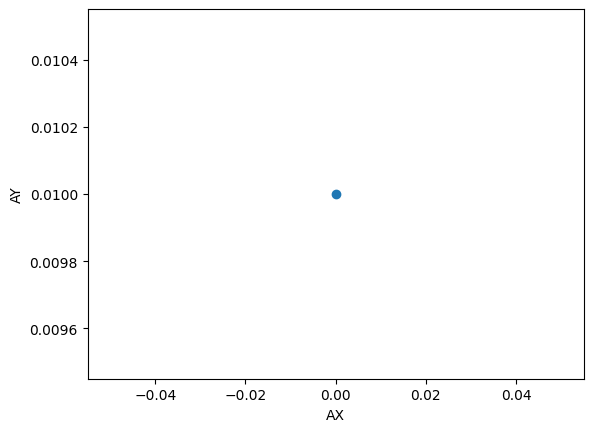

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
import serial
import matplotlib.pyplot as plt

# Open your Arduino COM port
ser = serial.Serial('COM6', 9600, timeout=1)

# Storage for values
xs, ys = [], []
max_points = 100  # keep last 100 points

# Initialize plot
plt.ion()
fig, ax = plt.subplots()
line, = ax.plot([], [], '-o')
ax.set_xlabel("AX")
ax.set_ylabel("AY")

while True:
    line_raw = ser.readline().decode(errors='ignore').strip()
    if line_raw:
        try:
            # Split into key=value parts
            parts = line_raw.split()

            # Example output:
            # GX=0.00 GY=0.00 GZ=0.00 AX=0.00 AY=0.01 AZ=1.00 MX=...
            ax_val = float(parts[3].split("=")[1])  # AX=...
            ay_val = float(parts[4].split("=")[1])  # AY=...

            xs.append(ax_val)
            ys.append(ay_val)

            xs = xs[-max_points:]
            ys = ys[-max_points:]

            # Update plot
            line.set_xdata(xs)
            line.set_ydata(ys)
            ax.relim()
            ax.autoscale_view()
            plt.draw()
            plt.pause(0.01)

        except Exception as e:
            print("Parse error:", e, "| Line:", line_raw)


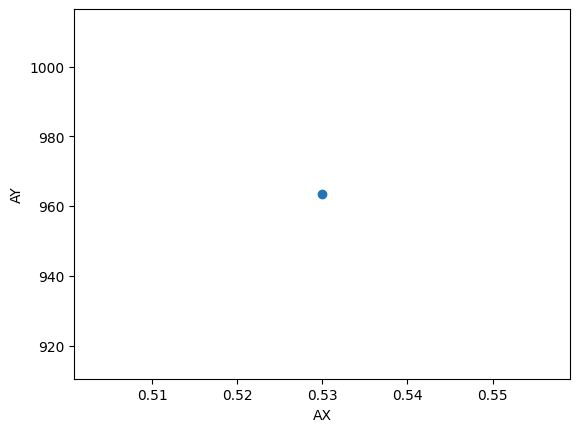

KeyboardInterrupt: 

In [1]:
import serial
import matplotlib.pyplot as plt

ser = serial.Serial('COM6', 9600, timeout=1)

xs, ys = [], []

plt.ion()
fig, ax = plt.subplots()

while True:
    line = ser.readline().decode(errors='ignore').strip()
    if line:
        try:
            # Example: extract AX and AY values from message
            parts = line.split()
            ax_val = float(parts[1].split("=")[1])   # AX=...
            ay_val = float(parts[2].split("=")[1])   # AY=...

            xs.append(ax_val)
            ys.append(ay_val)

            ax.clear()
            ax.plot(xs, ys, '-o')
            ax.set_xlabel("AX")
            ax.set_ylabel("AY")
            plt.pause(0.01)
        except Exception as e:
            print("Parse error:", e, "| Line:", line)
